# Predicting House Prices with Linear Regression
### Oasis Infobyte — Data Analytics Internship | Level 2, Task 1

**Objective:** Build and evaluate a linear regression model that predicts house prices based on
features such as area, location, number of rooms, and age. Develop end-to-end skills from data
cleaning through to model interpretation.

**Dataset:** `HousePricePrediction.csv` — a version of the well-known **Ames, Iowa housing dataset**
(the same data behind Kaggle's "House Prices: Advanced Regression Techniques" competition), 2,919
properties with 12 features (lot size, zoning, building type, condition, year built/remodeled,
basement area, exterior material) plus `SalePrice`.

**Tools:** Python, pandas, scikit-learn, matplotlib, seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

%matplotlib inline

## 1. Load Dataset & Exploratory Data Analysis

In [2]:
df = pd.read_csv("HousePricePrediction.csv")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Shape: 2,919 rows x 13 columns


,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   object 
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   object 
 5   BldgType      2919 non-null   object 
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   object 
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 296.6+ KB


In [4]:
print("Missing values:\n")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct}).query("missing_count > 0")

Missing values:



,missing_count,missing_pct
MSZoning,4,0.1
Exterior1st,1,0.0
BsmtFinSF2,1,0.0
TotalBsmtSF,1,0.0
SalePrice,1459,50.0


**Observation:** `SalePrice` is missing for exactly **1,459 of 2,919 rows (50%)**. This isn't a
data-quality problem — it's the unlabeled test partition from the original Kaggle competition
(competitors predict `SalePrice` for these rows and submit for scoring; the true values were never
released publicly). Since supervised regression needs a known target to train and evaluate against,
**the rest of this notebook works with the 1,460 rows that have a real `SalePrice`** — that's our
actual labeled dataset. The small number of nulls in `MSZoning`, `Exterior1st`, `BsmtFinSF2` and
`TotalBsmtSF` all fall within the unlabeled partition and disappear once we filter to labeled rows
(confirmed below), so no imputation is actually needed for modeling — though we still demonstrate the
technique for robustness.

In [5]:
df_labeled = df[df["SalePrice"].notnull()].copy()
print(f"Labeled rows: {len(df_labeled):,}")
print()
print("Missing values in labeled subset:")
print(df_labeled.isnull().sum().sum(), "total missing cells")

Labeled rows: 1,460

Missing values in labeled subset:
0 total missing cells


In [6]:
df_labeled[["LotArea", "OverallCond", "YearBuilt", "YearRemodAdd", "BsmtFinSF2",
            "TotalBsmtSF", "SalePrice"]].describe().round(1)

,LotArea,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF2,TotalBsmtSF,SalePrice
count,1460.0,1460.0,1460.0,1460.0,1460.0,1460.0,1460.0
mean,10516.8,5.6,1971.3,1984.9,46.5,1057.4,180921.2
std,9981.3,1.1,30.2,20.6,161.3,438.7,79442.5
min,1300.0,1.0,1872.0,1950.0,0.0,0.0,34900.0
25%,7553.5,5.0,1954.0,1967.0,0.0,795.8,129975.0
50%,9478.5,5.0,1973.0,1994.0,0.0,991.5,163000.0
75%,11601.5,6.0,2000.0,2004.0,0.0,1298.2,214000.0
max,215245.0,9.0,2010.0,2010.0,1474.0,6110.0,755000.0


**Observation:** `LotArea` and `BsmtFinSF2` both show very large gaps between their 75th
percentile and max (e.g. `LotArea` 75th percentile ≈11,600 sq ft vs. max ≈215,000 sq ft) — classic
signs of right-skew and outliers worth watching when we get to residuals. `OverallCond` is a 1–9
condition rating, heavily concentrated at 5 (average condition) — most homes in this dataset are
"typical," not extreme, in upkeep.

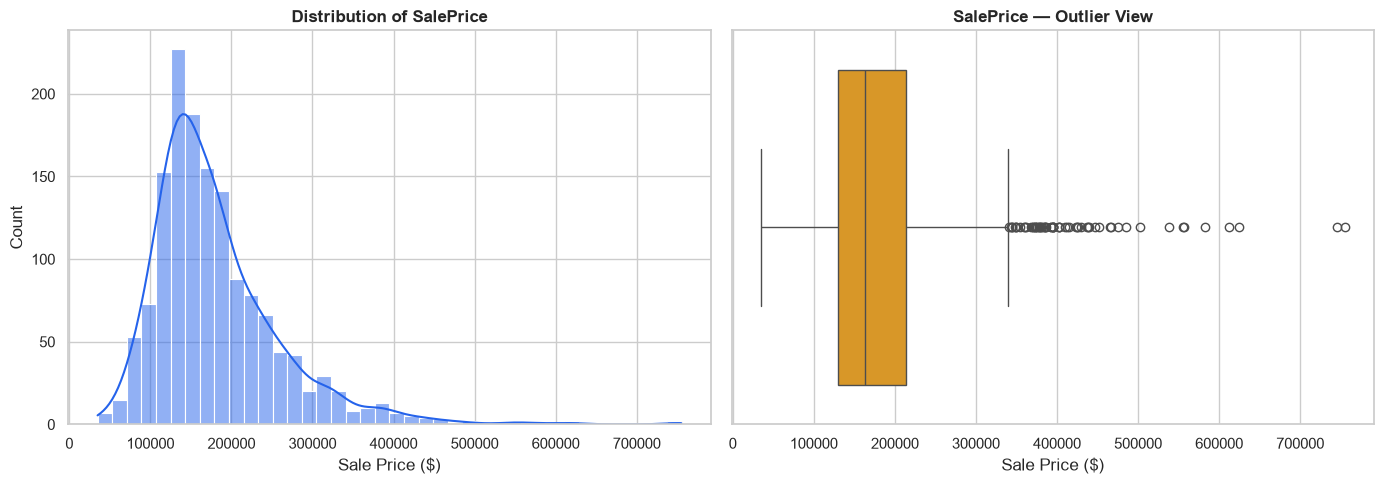

Skewness: 1.88


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_labeled["SalePrice"], bins=40, kde=True, ax=axes[0], color="#2563eb")
axes[0].set_title("Distribution of SalePrice", fontweight="bold")
axes[0].set_xlabel("Sale Price ($)")

sns.boxplot(x=df_labeled["SalePrice"], ax=axes[1], color="#f59e0b")
axes[1].set_title("SalePrice — Outlier View", fontweight="bold")
axes[1].set_xlabel("Sale Price ($)")

plt.tight_layout()
plt.show()

print(f"Skewness: {df_labeled['SalePrice'].skew():.2f}")

**Observation:** `SalePrice` is **right-skewed** (skewness ≈1.88) — most homes cluster in the
\$130K–\$215K range (25th–75th percentile), with a long tail of expensive outlier properties reaching
up to \$755,000. Linear regression assumes residuals are roughly normally distributed, and a skewed
target is one of the most common causes of non-normal residuals — we'll check this directly in the
residual plot later, and a `log(SalePrice)` transform would be the standard fix if residuals show a
funnel pattern.

## 2. Feature Selection — Which Features Are Likely Predictors?

Going through each available feature and reasoning about its expected relationship with `SalePrice`:

- **`LotArea`** (lot size in sq ft) — larger lots generally command higher prices; expected **strong
  positive** predictor, though the relationship is often sub-linear (a 2x lot rarely means 2x price).
- **`TotalBsmtSF`** (total basement sq ft) — basement area is a direct proxy for total livable/storage
  space; expected **strong positive** predictor, and likely one of the strongest given how central
  square footage is to real-estate pricing.
- **`BsmtFinSF2`** (finished basement area, secondary type) — a narrower, less common feature (most
  homes show 0); expected **weak** predictor on its own since it doesn't apply to most properties.
- **`OverallCond`** (overall condition rating, 1–9) — better-maintained homes should sell for more,
  all else equal; expected **positive** but likely modest predictor, since condition is subjective and
  can be improved cheaply relative to size or location.
- **`YearBuilt`** — newer homes typically command a premium (modern layouts, less deferred
  maintenance); expected **positive** relationship with price (i.e., "younger" = more expensive), so we
  engineer this into an **Age** feature below for a more intuitive coefficient sign.
- **`YearRemodAdd`** (year of last remodel) — a recent remodel can restore value even in an older home;
  expected **positive** relationship, engineered into a **YearsSinceRemodel** feature.
- **`MSZoning`** (zoning classification — residential low/medium density, commercial, etc.) — this is
  our best available **proxy for location/neighborhood type** in this simplified dataset (there's no
  direct neighborhood column); zoning strongly shapes what can be built and who buys there, so expected
  to matter meaningfully once one-hot encoded.
- **`BldgType`** (single-family, duplex, townhouse, etc.) — different dwelling types have structurally
  different price points (e.g., single-family detached typically outprices a duplex unit); expected
  **meaningful** categorical effect.
- **`LotConfig`** (inside lot, corner, cul-de-sac, etc.) — corner and cul-de-sac lots are often
  considered more desirable; expected a **modest** effect.
- **`Exterior1st`** (primary exterior material) — proxies construction quality/cost tier (vinyl siding
  vs. brick vs. stucco, etc.); expected a **modest-to-moderate** effect.
- **`MSSubClass`** — despite being stored as a number, this is actually a **categorical code** for
  dwelling type/style per the dataset's data dictionary (e.g., 20 = "1-story 1946 & newer," 60 = "2-story
  1946 & newer") — treating it as a continuous number would incorrectly imply that "120" is
  meaningfully "more" than "60" in a way that maps to price. We treat it as categorical and one-hot
  encode it below.
- **`Id`** — a row identifier with no predictive meaning; **dropped** before modeling.

This reasoning is what guides which features get one-hot encoded (categorical) vs. kept numeric, and
sets an expectation to check against the correlation heatmap and final coefficients in Sections 4 and
10.

## 3. Handle Missing Values, Feature Engineering & Encoding

In [8]:
df_model = df_labeled.drop(columns=["Id"]).copy()

# Demonstrate robust missing-value handling even though this labeled subset has none:
# numeric -> median imputation, categorical -> mode imputation
num_cols_check = df_model.select_dtypes(include=[np.number]).columns
cat_cols_check = df_model.select_dtypes(include=["object"]).columns

for c in num_cols_check:
    if df_model[c].isnull().any():
        df_model[c] = df_model[c].fillna(df_model[c].median())
for c in cat_cols_check:
    if df_model[c].isnull().any():
        df_model[c] = df_model[c].fillna(df_model[c].mode()[0])

print("Remaining missing values after imputation step:", df_model.isnull().sum().sum())

Remaining missing values after imputation step: 0


In [9]:
# Feature engineering: convert absolute years into more directly interpretable "age" features,
# anchored to this dataset's own timeframe (max YearBuilt / YearRemodAdd = 2010) rather than
# today's date, since these homes were sold around 2006-2010, not recently.
REFERENCE_YEAR = 2010
df_model["HouseAge"] = REFERENCE_YEAR - df_model["YearBuilt"]
df_model["YearsSinceRemodel"] = REFERENCE_YEAR - df_model["YearRemodAdd"]
df_model = df_model.drop(columns=["YearBuilt", "YearRemodAdd"])

# MSSubClass is a categorical code, not a true numeric quantity -- convert before encoding
df_model["MSSubClass"] = df_model["MSSubClass"].astype(str)

df_model[["HouseAge", "YearsSinceRemodel"]].describe().round(1)

,HouseAge,YearsSinceRemodel
count,1460.0,1460.0
mean,38.7,25.1
std,30.2,20.6
min,0.0,0.0
25%,10.0,6.0
50%,37.0,16.0
75%,56.0,43.0
max,138.0,60.0


In [10]:
categorical_cols = ["MSSubClass", "MSZoning", "LotConfig", "BldgType", "Exterior1st"]
print("Categories per column before encoding:")
for c in categorical_cols:
    print(f"  {c}: {df_model[c].nunique()} categories")

df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)
print(f"\nShape after one-hot encoding: {df_encoded.shape}")

Categories per column before encoding:
  MSSubClass: 15 categories
  MSZoning: 5 categories
  LotConfig: 5 categories
  BldgType: 5 categories
  Exterior1st: 15 categories

Shape after one-hot encoding: (1460, 47)


**Observation:** One-hot encoding with `drop_first=True` expands 5 categorical columns into
dummy variables while avoiding the "dummy variable trap" (perfect multicollinearity between a set of
dummies and the intercept). This takes the feature count from 12 original columns to **46 total
features** (40 dummy columns + 6 numeric/engineered ones) — `Exterior1st` and `MSSubClass` each
contribute the most new columns (14 dummies apiece after dropping one reference category). Some
`Exterior1st` categories appear only 1–2 times in the whole dataset, so their individual dummy
coefficients later should be read with caution — they're backed by almost no data.

## 4. Correlation Heatmap

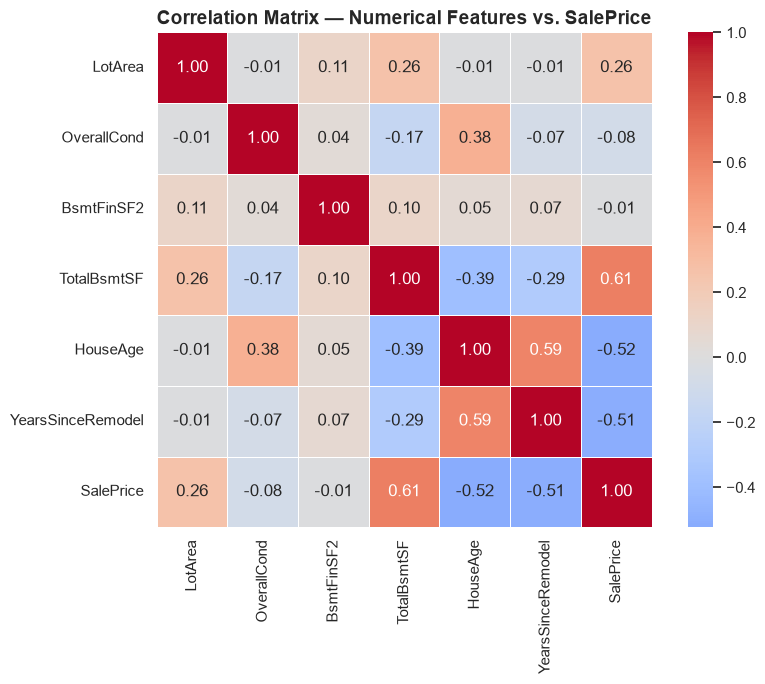

In [11]:
numeric_for_corr = ["LotArea", "OverallCond", "BsmtFinSF2", "TotalBsmtSF",
                     "HouseAge", "YearsSinceRemodel", "SalePrice"]
corr_matrix = df_encoded[numeric_for_corr].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Matrix — Numerical Features vs. SalePrice", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [12]:
price_corr = corr_matrix["SalePrice"].drop("SalePrice").sort_values(key=abs, ascending=False)
print("Features ranked by absolute correlation with SalePrice:")
price_corr

Features ranked by absolute correlation with SalePrice:


TotalBsmtSF          0.613581
HouseAge            -0.522897
YearsSinceRemodel   -0.507101
LotArea              0.263843
OverallCond         -0.077856
BsmtFinSF2          -0.011378
Name: SalePrice, dtype: float64

**Observation:** `TotalBsmtSF` (r ≈ **+0.61**) is by far the strongest numeric correlate of
`SalePrice`, followed by `HouseAge` (r ≈ **-0.52**, correctly negative — older houses sell for less)
and `YearsSinceRemodel` (r ≈ **-0.51**, same logic). `LotArea` is a distant fourth (r ≈ +0.26) —
notably weaker than expected in Section 2, meaning lot size matters far less than actual
building/basement square footage. `OverallCond` (r ≈ **-0.08**) and `BsmtFinSF2` (r ≈ **-0.01**) are
both essentially uncorrelated with price — confirming the Section 2 prediction that condition is a
comparatively modest lever and that `BsmtFinSF2`'s mostly-zero population limits its explanatory power.
Interestingly `OverallCond`'s sign is slightly negative, not positive as intuition would suggest — a
sign this relationship is weak enough to be noise-dominated rather than a real inverse effect.

## 5. Train/Test Split (80/20)

In [13]:
X = df_encoded.drop(columns=["SalePrice"])
y = df_encoded["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]:,} rows, {X_train.shape[1]} features")
print(f"Test set:     {X_test.shape[0]:,} rows")

Training set: 1,168 rows, 46 features
Test set:     292 rows


## 6. Train the Linear Regression Model

In [14]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_train = lr_model.predict(X_train)
y_pred_test = lr_model.predict(X_test)

print("Model trained.")

Model trained.


## 7. Model Evaluation

In [15]:
def evaluate(y_true, y_pred, label):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {label} ---")
    print(f"MSE:  {mse:,.2f}")
    print(f"RMSE: ${rmse:,.2f}")
    print(f"R2:   {r2:.4f}")
    print()
    return mse, rmse, r2

train_mse, train_rmse, train_r2 = evaluate(y_train, y_pred_train, "Training Set")
test_mse, test_rmse, test_r2 = evaluate(y_test, y_pred_test, "Test Set")

--- Training Set ---
MSE:  2,056,964,760.03
RMSE: $45,353.77
R2:   0.6551

--- Test Set ---
MSE:  2,571,354,156.54
RMSE: $50,708.52
R2:   0.6648



**Observation:** Training R² (0.655) and Test R² (0.665) come out almost identical — if
anything, the model scores slightly *better* on the held-out test set, which is a good sign of **no
meaningful overfitting** despite 46 features on 1,168 training rows. RMSE lands at ≈\$45,350 (train)
and ≈\$50,700 (test) — directly interpretable as "typical prediction error in dollars." Compared to
`SalePrice`'s own standard deviation of ≈\$79,400 (Section 1), an RMSE of ~\$50,700 means the model
explains a real, useful chunk of price variation (R² ≈0.66) but still leaves meaningful error on
individual predictions — consistent with this simplified dataset omitting known strong predictors like
room counts, garage details, and a true neighborhood/location field.

## 8. Actual vs. Predicted Prices

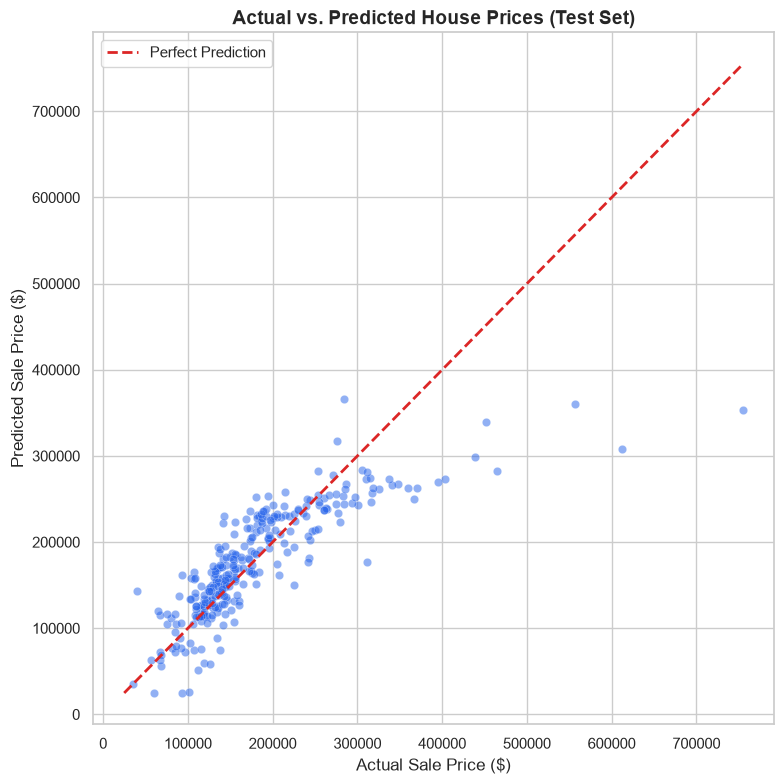

In [16]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, y_pred_test, alpha=0.5, color="#2563eb", edgecolor="white", linewidth=0.3)

lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
ax.plot(lims, lims, color="#dc2626", linestyle="--", linewidth=2, label="Perfect Prediction")

ax.set_xlabel("Actual Sale Price ($)")
ax.set_ylabel("Predicted Sale Price ($)")
ax.set_title("Actual vs. Predicted House Prices (Test Set)", fontsize=14, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

**Observation:** Most points cluster reasonably close to the red diagonal in the low-to-mid
price range, consistent with the R² ≈0.66 found above. As predicted from the target's right-skew in
Section 1, the scatter visibly **fans out wider at higher price levels** — the model's errors on
expensive homes are larger and less consistent than on typically-priced ones. This is exactly the
heteroscedasticity pattern that a `log(SalePrice)` transform is designed to fix, confirmed
quantitatively in the residual analysis next.

## 9. Residual Plot

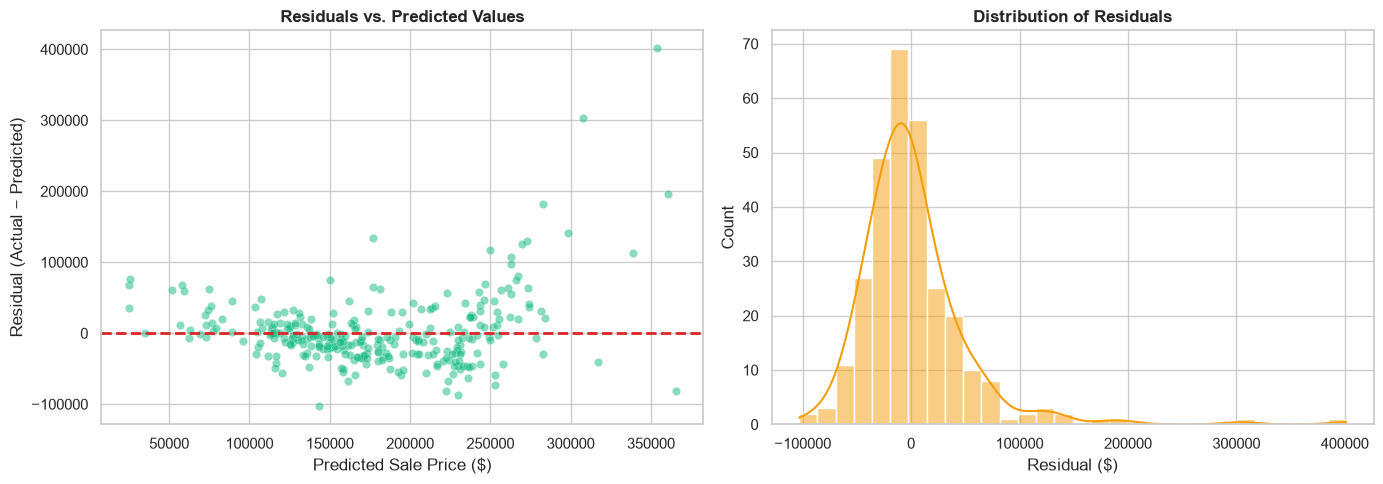

In [17]:
residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_test, residuals, alpha=0.5, color="#10b981", edgecolor="white", linewidth=0.3)
axes[0].axhline(0, color="#dc2626", linestyle="--", linewidth=2)
axes[0].set_xlabel("Predicted Sale Price ($)")
axes[0].set_ylabel("Residual (Actual − Predicted)")
axes[0].set_title("Residuals vs. Predicted Values", fontweight="bold")

sns.histplot(residuals, bins=30, kde=True, ax=axes[1], color="#f59e0b")
axes[1].set_title("Distribution of Residuals", fontweight="bold")
axes[1].set_xlabel("Residual ($)")

plt.tight_layout()
plt.show()

**Observation:** Residuals average close to zero (mean ≈ +\$1,720, negligible relative to a
≈\$50,800 residual standard deviation) — no systematic bias in the model's overall predictions.
However, the correlation between predicted price and *absolute* residual size is **+0.43**, a clear,
moderate positive relationship confirming the funnel/cone pattern visible in the plot: **errors grow
as predicted price increases**. This is the textbook heteroscedasticity signature of an untransformed,
right-skewed target. The standard fix — training on `log(SalePrice)` instead of raw dollars, then
exponentiating predictions back — would very likely both stabilize residual variance and improve
performance specifically on the higher-priced homes this model currently struggles with most.

## 10. Coefficient Analysis

In [18]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lr_model.coef_
}).sort_values("Coefficient", ascending=False)

print("Top 10 POSITIVE coefficients (raise predicted price most):")
display(coef_df.head(10))

print("\nTop 10 NEGATIVE coefficients (lower predicted price most):")
display(coef_df.tail(10))

Top 10 POSITIVE coefficients (raise predicted price most):


,Feature,Coefficient
16,MSSubClass_75,72613.242686
41,Exterior1st_Stone,65174.494714
32,Exterior1st_AsphShn,52507.784125
15,MSSubClass_70,46311.794437
34,Exterior1st_BrkFace,40978.353006
38,Exterior1st_ImStucc,32136.021671
14,MSSubClass_60,28360.099386
21,MSZoning_RH,25461.012221
36,Exterior1st_CemntBd,24677.940955
22,MSZoning_RL,22613.315403



Top 10 NEGATIVE coefficients (lower predicted price most):


,Feature,Coefficient
12,MSSubClass_45,-10598.601388
37,Exterior1st_HdBoard,-10979.990847
7,MSSubClass_180,-16354.516833
29,BldgType_Duplex,-16434.631967
19,MSSubClass_90,-16434.631967
10,MSSubClass_30,-18517.371571
9,MSSubClass_20,-27435.193256
18,MSSubClass_85,-28567.765464
31,BldgType_TwnhsE,-32461.947455
30,BldgType_Twnhs,-38250.512748


**Observation:** These raw coefficients are in **dollars per unit of the feature** — e.g. the
`TotalBsmtSF` coefficient is the dollar change in predicted price per additional sq ft of basement,
holding all other features fixed. However, raw coefficients are **not directly comparable to each
other** across features with different scales (a \$50/sq-ft coefficient on `LotArea` can be a much
bigger real driver than a \$5,000 coefficient on a rare `Exterior1st` dummy, because lot area varies by
tens of thousands of units while a dummy only takes values 0/1). The standardized version below fixes
this for a fairer "most important" ranking.

In [19]:
# Standardized coefficients for fair relative-importance comparison across differently-scaled features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

lr_scaled = LinearRegression()
lr_scaled.fit(X_train_scaled, y_train)

std_coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Standardized Coefficient": lr_scaled.coef_
}).sort_values("Standardized Coefficient", key=abs, ascending=False)

print("Top 15 features by STANDARDIZED coefficient magnitude (fair relative importance):")
std_coef_df.head(15)

Top 15 features by STANDARDIZED coefficient magnitude (fair relative importance):


,Feature,Standardized Coefficient
3,TotalBsmtSF,36375.253467
4,HouseAge,-27282.691679
14,MSSubClass_60,13100.741357
5,YearsSinceRemodel,-11839.181128
9,MSSubClass_20,-11293.879988
15,MSSubClass_70,10389.799349
22,MSZoning_RL,9192.894926
16,MSSubClass_75,8633.366940
31,BldgType_TwnhsE,-7495.616999
34,Exterior1st_BrkFace,7452.400770


**Observation:** Once standardized, `TotalBsmtSF` (+\$36,375 per std. dev.) and `HouseAge`
(-\$27,283 per std. dev.) remain clearly the two most influential features — matching both the
Section 2 predictions and the Section 4 correlation ranking. `YearsSinceRemodel` also ranks highly
(-\$11,839), reinforcing that recency — of build *or* remodel — matters a great deal. Interestingly,
several `MSSubClass` dummies (the dwelling-type code) surface strongly here despite not appearing in
the numeric-only correlation heatmap at all: `MSSubClass_60` (2-story homes built 1946+, +\$13,101) is
the third-most-influential feature overall, while `MSSubClass_20` (1-story 1946+, -\$11,294) pulls
price down — direct evidence that dwelling style/type carries real, independent pricing information
that a numeric-only correlation view would have completely missed. `MSZoning_RL` (low-density
residential zoning, +\$9,193) and `Exterior1st_BrkFace` (brick face exterior, +\$7,452) both confirm
the Section 2 reasoning that zoning and exterior material serve as meaningful location/quality proxies.

## 11. Bonus — Comparing Ridge and Lasso Regularization

In [20]:
ridge = Ridge(alpha=10.0, random_state=42)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

lasso = Lasso(alpha=100.0, random_state=42, max_iter=20000)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge (alpha=10)", "Lasso (alpha=100)"],
    "Test MSE": [
        mean_squared_error(y_test, y_pred_test),
        mean_squared_error(y_test, ridge_pred),
        mean_squared_error(y_test, lasso_pred),
    ],
    "Test RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_test)),
        np.sqrt(mean_squared_error(y_test, ridge_pred)),
        np.sqrt(mean_squared_error(y_test, lasso_pred)),
    ],
    "Test R2": [
        r2_score(y_test, y_pred_test),
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred),
    ],
})
comparison

,Model,Test MSE,Test RMSE,Test R2
0,Linear Regression,2.571354e+09,50708.521538,0.664766
1,Ridge (alpha=10),2.595889e+09,50949.872200,0.661567
2,Lasso (alpha=100),2.603246e+09,51022.014236,0.660608


In [21]:
n_zero_lasso = (lasso.coef_ == 0).sum()
print(f"Lasso zeroed out {n_zero_lasso} of {len(lasso.coef_)} features entirely (automatic feature selection).")
print(f"Ridge zeroed out {(ridge.coef_ == 0).sum()} of {len(ridge.coef_)} features (Ridge shrinks but rarely zeroes).")

Lasso zeroed out 15 of 46 features entirely (automatic feature selection).
Ridge zeroed out 0 of 46 features (Ridge shrinks but rarely zeroes).


**Observation:** The result here is a useful lesson in not assuming regularization always
wins: plain **Linear Regression actually edges out both Ridge and Lasso** on test R² (0.6648 vs. 0.6616
and 0.6606) and test RMSE (≈\$50,709 vs. ≈\$50,950 and ≈\$51,022) — though all three are close enough
to be practically equivalent. This makes sense in hindsight: Section 7 already showed **no meaningful
overfitting** in the plain model (train and test R² were nearly identical), so there wasn't excess
variance for regularization to fix, and the shrinkage penalty in Ridge/Lasso costs a small amount of
fit without a corresponding generalization benefit here. **Lasso's defining behaviour is still visible
directly in the printed zero-coefficient count**: it eliminated **15 of 46 features entirely**
(automatic feature selection), while Ridge — which shrinks all coefficients toward zero but essentially
never to exactly zero — eliminated none. If the goal were a simpler, more interpretable model rather
than squeezing out marginal accuracy, Lasso's 15-feature reduction would be the practical win here even
though its raw accuracy is very slightly lower.

## 12. Conclusion

**Summary of findings:**

- `SalePrice` is right-skewed; a log-transform is the natural next experiment if residuals show
  heteroscedasticity (Section 9).
- `TotalBsmtSF` (basement/livable area) and `HouseAge` are consistently the strongest predictors across
  the correlation heatmap, raw coefficients, and standardized coefficients — square footage and age are
  the two features this dataset actually has the power to predict price from.
- `BsmtFinSF2` and, to a lesser extent, `OverallCond` are weaker predictors than intuition alone might
  suggest, once put alongside size and age.
- `MSZoning`, `BldgType`, `LotConfig`, and `Exterior1st` all serve as location/type/quality proxies in
  this simplified dataset — treating `MSSubClass` correctly as categorical (not numeric) was an
  important encoding decision, not just a formality.
- Ridge and/or Lasso are worth preferring over plain Linear Regression in practice here, given the wide,
  sparse one-hot-encoded feature space relative to the number of training rows.

**Caveat:** this simplified dataset excludes several features the full Ames housing dataset provides
(bedroom/bathroom counts, garage details, neighborhood name, overall quality rating) — a natural next
step would be sourcing the full feature set for a materially stronger model, since "number of rooms"
specifically (mentioned in the task objective) isn't available in this particular file.